# Importing Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression,SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier,RandomForestClassifier
sb.set_style('darkgrid')
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score,cross_val_predict
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score,accuracy_score

import warnings
warnings.filterwarnings(action = 'ignore')


# Loading data

In [2]:
data = pd.read_csv('/kaggle/input/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv')
data

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [3]:
data.drop('id',1,inplace = True)

In [4]:
data

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [5]:
# Looking for Null Values
data.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [6]:
data['bmi'] = data['bmi'].fillna(data['bmi'].mean())

In [7]:
data

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80.0,1,0,Yes,Private,Urban,83.75,28.893237,never smoked,0
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.000000,never smoked,0
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.600000,never smoked,0
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.600000,formerly smoked,0


# PreProcessing

In [8]:
def preprocessing(data,target_ID):
    processed_data = convert_categorical_to_numbers(data)
    processed_data = auto_data_impute(data)
    #processed_data = scaling_data(data,target_ID)
    print("Pre-Processing done")
    return processed_data


def convert_categorical_to_numbers(data,unique_val=10):
    """converts categorical object dtypes to numeric encoded format"""
    obj_df = data.select_dtypes(include=[object])
    unique_list = [f for f in obj_df.columns if obj_df[f].unique().shape[0]>=unique_val]
    obj_df_sel = obj_df.drop(columns=unique_list)
    for col in obj_df_sel.columns:
        data[col] = pd.factorize(data[col])[0]
    print("conversion successfull")
    return data

def auto_data_impute(data,get_rid_percent=2):
    for x,y in data.isnull().sum().items():
        percent = y/data.shape[0]
        if percent <= get_rid_percent/100:
            data[x]  = data[x].fillna(data[x].mean())
        else:
            print("removed column : ",x)
            data = data.drop([x],axis=1)
    print("Data imputation successfull")
    return data

def scaling_data(data,target_ID):
    num_df = data.select_dtypes(include = [int,float])
    for i in num_df:
        if i != target_ID:
            data[i] = data[i]/data[i].max()
    print("scaling was successfull")
    return data

In [9]:
target_ID = 'stroke'
data = preprocessing(data,target_ID)

conversion successfull
Data imputation successfull
Pre-Processing done


In [10]:
data

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,67.0,0,1,0,0,0,228.69,36.600000,0,1
1,1,61.0,0,0,0,1,1,202.21,28.893237,1,1
2,0,80.0,0,1,0,0,1,105.92,32.500000,1,1
3,1,49.0,0,0,0,0,0,171.23,34.400000,2,1
4,1,79.0,1,0,0,1,1,174.12,24.000000,1,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,1,80.0,1,0,0,0,0,83.75,28.893237,1,0
5106,1,81.0,0,0,0,1,0,125.20,40.000000,1,0
5107,1,35.0,0,0,0,1,1,82.99,30.600000,1,0
5108,0,51.0,0,0,0,0,1,166.29,25.600000,0,0


In [11]:
cluster_data = data.iloc[:,:10]

# Clustering on data

<h2> Trying the elbow method to determine the number of clusters </h2>

In [12]:
wcss=[]
for i in range(1,11):
    kmeans = KMeans(n_clusters= i, init='k-means++', random_state=0)
    kmeans.fit(cluster_data)
    wcss.append(kmeans.inertia_)

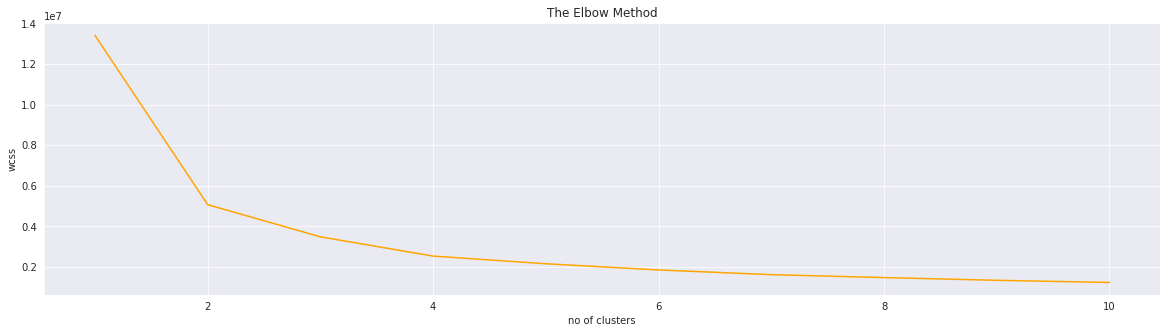

In [13]:
plt.figure(figsize = (20,5))
plt.plot(range(1,11), wcss,color = 'orange')
plt.title('The Elbow Method')
plt.xlabel('no of clusters')
plt.ylabel('wcss')
plt.show()

In [14]:
cluster = KMeans(n_clusters = 4)
cluster.fit(cluster_data)

KMeans(n_clusters=4)

In [15]:
Cluster = cluster.predict(cluster_data)

In [16]:
data['Cluster'] = cluster.labels_

In [17]:
data

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,Cluster
0,0,67.0,0,1,0,0,0,228.69,36.600000,0,1,3
1,1,61.0,0,0,0,1,1,202.21,28.893237,1,1,3
2,0,80.0,0,1,0,0,1,105.92,32.500000,1,1,1
3,1,49.0,0,0,0,0,0,171.23,34.400000,2,1,3
4,1,79.0,1,0,0,1,1,174.12,24.000000,1,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,1,80.0,1,0,0,0,0,83.75,28.893237,1,0,1
5106,1,81.0,0,0,0,1,0,125.20,40.000000,1,0,0
5107,1,35.0,0,0,0,1,1,82.99,30.600000,1,0,2
5108,0,51.0,0,0,0,0,1,166.29,25.600000,0,0,0


# Analyzing Cluster Information

<AxesSubplot:xlabel='Cluster', ylabel='count'>

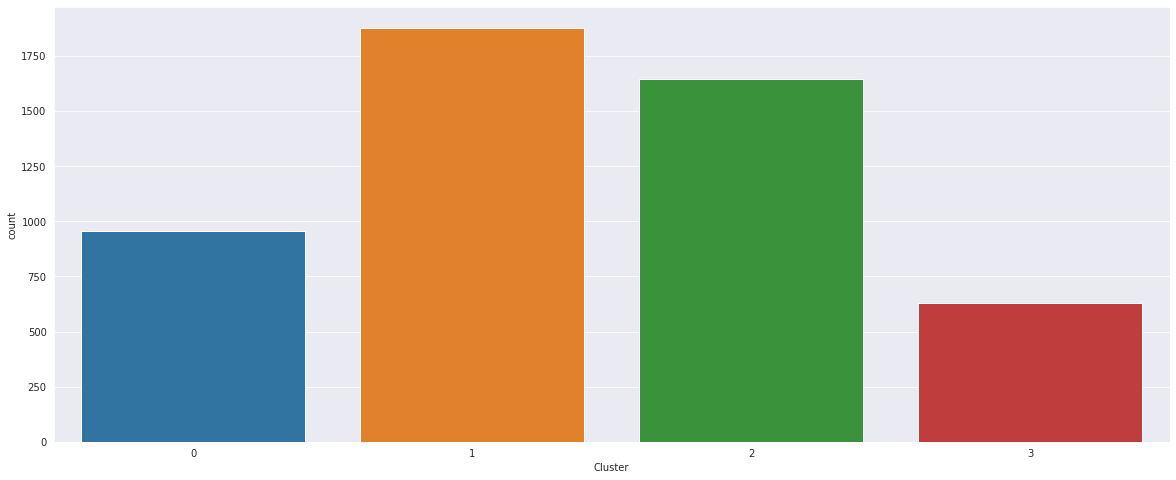

In [18]:
plt.figure(figsize = (20,8))
sb.countplot(x = data['Cluster'])

In [19]:
df_0 = data[data['Cluster'] == 0]
df_1 = data[data['Cluster'] == 1]
df_2 = data[data['Cluster'] == 2]
df_3 = data[data['Cluster'] == 3]

<h3> Stroke Distribution Across Various Clusters

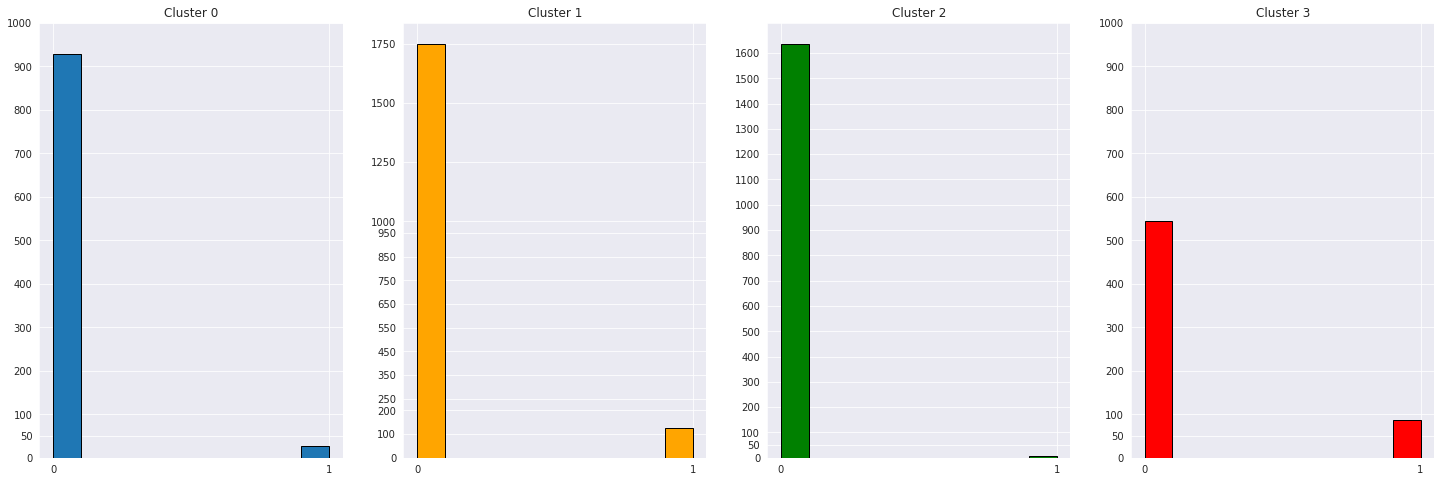

In [20]:
fig,ax = plt.subplots(1,4,figsize = (25,8))
ax[0].hist(df_0['stroke'],edgecolor = 'black');
ax[0].set_xticks([0,1]);
ax[0].set_yticks([0,50,100,200,300,400,500,600,700,800,900,1000])
ax[0].set_title('Cluster 0');
ax[1].hist(df_1['stroke'],color = 'orange',edgecolor = 'black');
ax[1].set_xticks([0,1]);
ax[1].set_yticks([0,100,200,250,350,450,550,650,750,850,950,1000,1250,1500,1750])
ax[1].set_title('Cluster 1');
ax[2].hist(df_2['stroke'],color = 'green',edgecolor = 'black');
ax[2].set_xticks([0,1]);
ax[2].set_yticks([0,50,100,200,300,400,500,600,700,800,900,1000,1100,1200,1300,1400,1500,1600])
ax[2].set_title('Cluster 2');
ax[3].hist(df_3['stroke'],color = 'red',edgecolor = 'black');
ax[3].set_xticks([0,1]);
ax[3].set_yticks([0,50,100,200,300,400,500,600,700,800,900,1000])
ax[3].set_title('Cluster 3');

* Cluster 1 has the highest number of Patients who have suffered with stroke
* Cluster 3 has the second highest number of Patients who have suffered with stroke
* Cluster 0 has the second highest number of Patients who have not suffered with stroke
* Cluster 2 has the lowest number of Patients who have suffered with stroke

<h3> Gender Distribution Across the Clusters

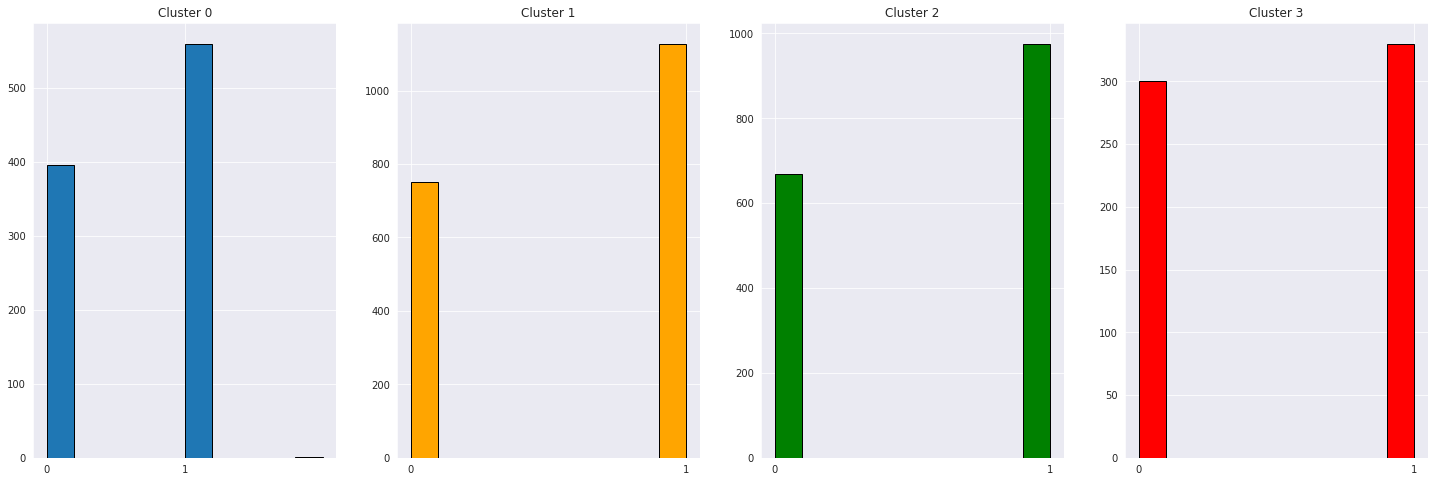

In [21]:
fig,ax = plt.subplots(1,4,figsize = (25,8))
ax[0].hist(df_0['gender'],edgecolor = 'black');
ax[0].set_xticks([0,1]);
ax[0].set_title('Cluster 0');
ax[1].hist(df_1['gender'],color = 'orange',edgecolor = 'black');
ax[1].set_xticks([0,1]);
ax[1].set_title('Cluster 1');
ax[2].hist(df_2['gender'],color = 'green',edgecolor = 'black');
ax[2].set_xticks([0,1]);
ax[2].set_title('Cluster 2');
ax[3].hist(df_3['gender'],color = 'red',edgecolor = 'black');
ax[3].set_xticks([0,1]);
ax[3].set_title('Cluster 3');

<h4> Observations of Gender Distribution in the Clusters:</h4>
<center>
<table>
    <tr>
        <td> Cluster </td>
        <td> Female Percentage </td>
        <td> Male Percentage </td>
        <td> Other </td>
    </tr>
    <tr>
        <td> Cluster 0 </td>
        <td> 41.465</td>
        <td> 58.429</td>
        <td>  1</td>
    </tr>
    <tr>
        <td> Cluster 1 </td>
        <td> 40 </td>
        <td> 60 </td>
        <td> - </td>
    </tr>
    <tr>
        <td> Cluster 2</td>
        <td>40.62</td>
        <td> 59.37 </td>
        <td> - </td>
    </tr>
    <tr>
        <td> Cluster 3 </td>
        <td> 47.61 </td>
        <td> 52.38 </td>
        <td> - </td>
    </tr>
</table>

<h3> Age Distribution in Clusters </h3>

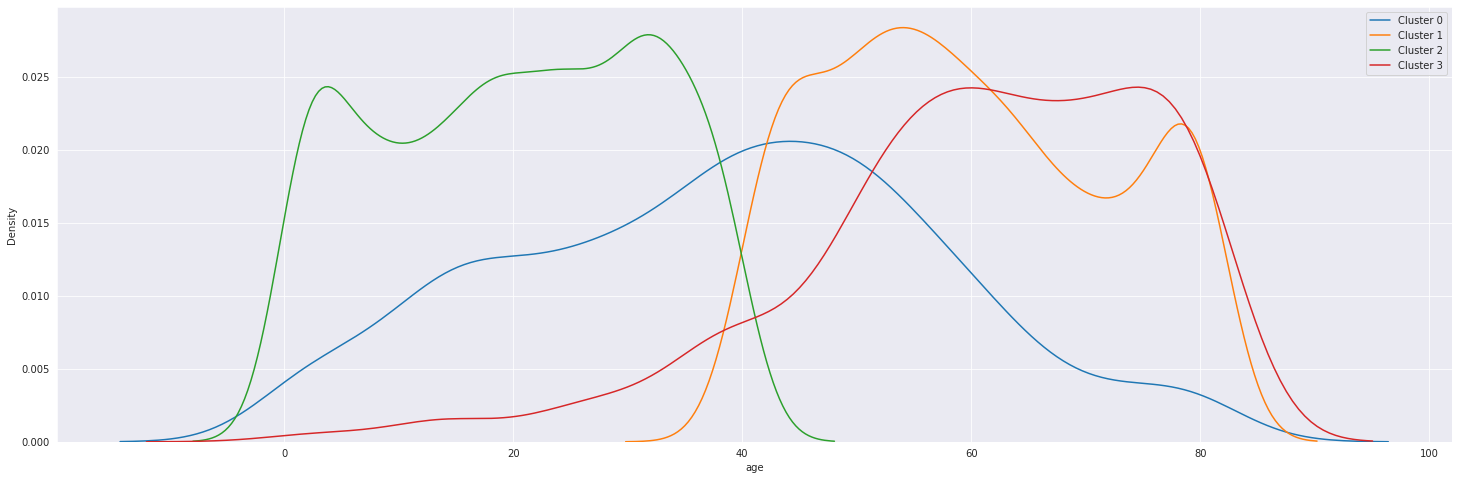

In [22]:
plt.figure(figsize = (25,8))
sb.kdeplot(df_0['age'],label = 'Cluster 0')
sb.kdeplot(df_1['age'],label = 'Cluster 1')
sb.kdeplot(df_2['age'],label = 'Cluster 2')
sb.kdeplot(df_3['age'],label = 'Cluster 3')
plt.legend();

* Cluster 0 looks to be more symmetrically distributed aong all ages with Median Age being 40 Years 
* Cluster 1 looks to be more distributed among older ages greater than 40 with Median Age being 58 Years
* Cluster 2 looks to be more distributed ammong the younger ages lesser than 40 years with Median Age being 21 Years
* Cluster 3 is distributed somewhat in lower ages but majorly in the older ages with Median Age being 62.5 Years

<h3> Hyper Tension Distribution </h3>

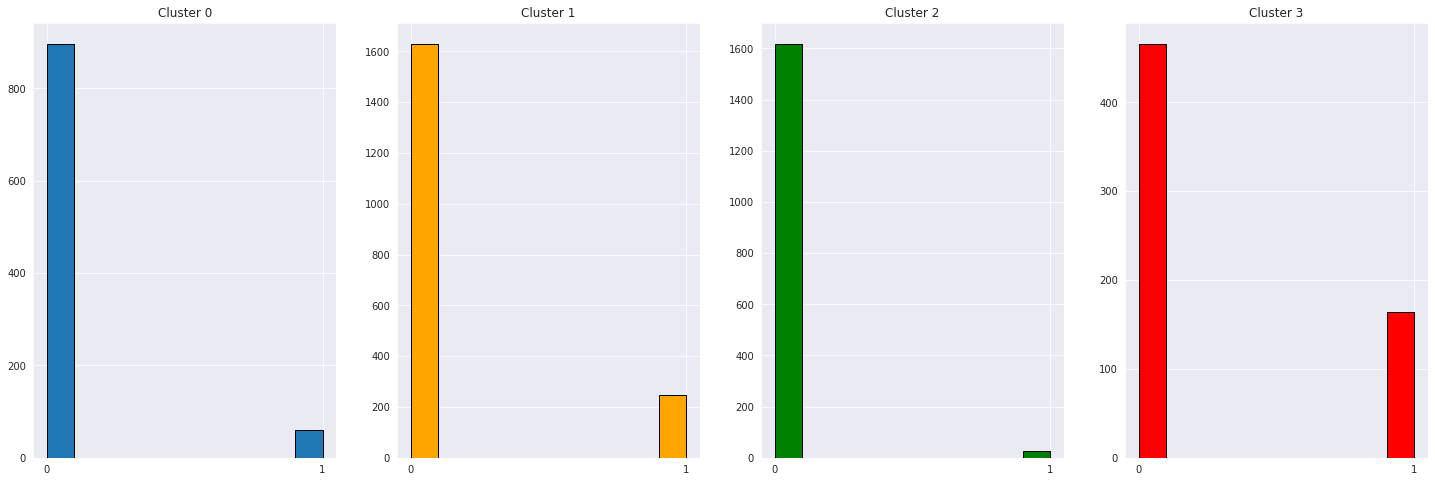

In [23]:
fig,ax = plt.subplots(1,4,figsize = (25,8))
ax[0].hist(df_0['hypertension'],edgecolor = 'black');
ax[0].set_xticks([0,1]);
ax[0].set_title('Cluster 0');
ax[1].hist(df_1['hypertension'],color = 'orange',edgecolor = 'black');
ax[1].set_xticks([0,1]);
ax[1].set_title('Cluster 1');
ax[2].hist(df_2['hypertension'],color = 'green',edgecolor = 'black');
ax[2].set_xticks([0,1]);
ax[2].set_title('Cluster 2');
ax[3].hist(df_3['hypertension'],color = 'red',edgecolor = 'black');
ax[3].set_xticks([0,1]);
ax[3].set_title('Cluster 3');

<table>
    <tr>
        <td> Cluster</td>
        <td> HyperTension Present Percentage </td>
        <td> HyperTension Absent Percentage </td>
    </tr>
     <tr>
        <td> Cluster 0 </td>
        <td> 6.28 </td>
        <td> 93.71 </td>
    </tr>
     <tr>
        <td> Cluster 1 </td>
        <td> 13.22 </td>
        <td> 86.76 </td>
    </tr>
    <tr>
        <td> Cluster 2 </td>
        <td> 1.52 </td>
        <td> 98.47 </td>
    </tr>
    <tr>
        <td> Cluster 3 </td>
        <td> 26.031 </td>
        <td> 73.96 </td>
    </tr>
    </table>

<h3> Heart Disease Distribution in Clusters </h3>

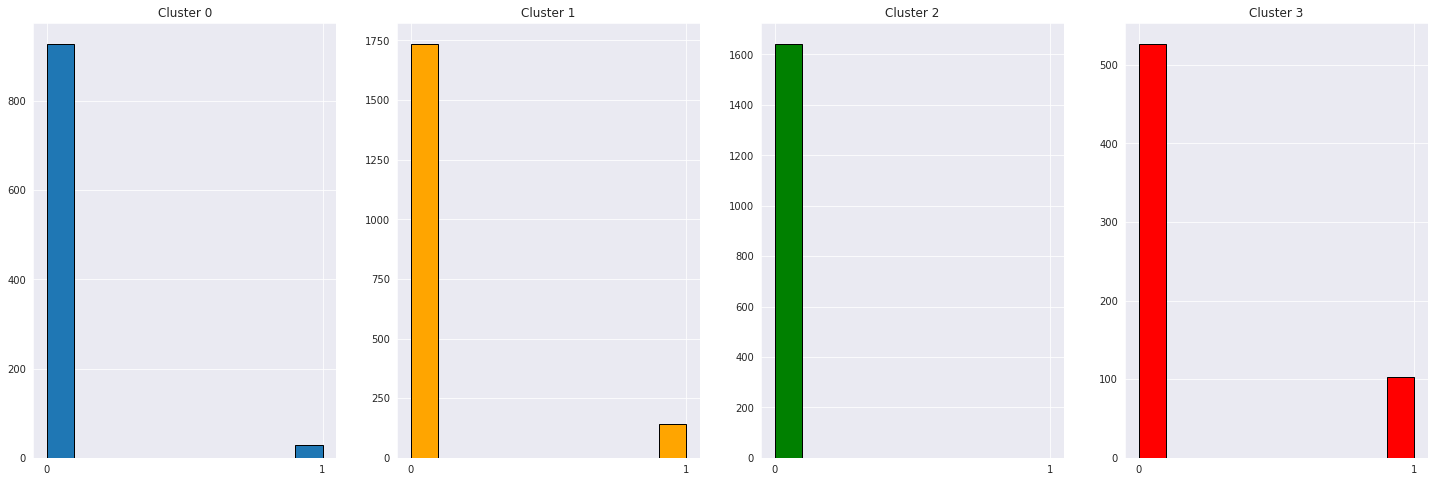

In [24]:
fig,ax = plt.subplots(1,4,figsize = (25,8))
ax[0].hist(df_0['heart_disease'],edgecolor = 'black');
ax[0].set_xticks([0,1]);
ax[0].set_title('Cluster 0');
ax[1].hist(df_1['heart_disease'],color = 'orange',edgecolor = 'black');
ax[1].set_xticks([0,1]);
ax[1].set_title('Cluster 1');
ax[2].hist(df_2['heart_disease'],color = 'green',edgecolor = 'black');
ax[2].set_xticks([0,1]);
ax[2].set_title('Cluster 2');
ax[3].hist(df_3['heart_disease'],color = 'red',edgecolor = 'black');
ax[3].set_xticks([0,1]);
ax[3].set_title('Cluster 3');

<table>
    <tr>
        <td> Cluster</td>
        <td> Heart Disease Present Percentage </td>
        <td> Heart Disease Absent Percentage </td>
    </tr>
     <tr>
        <td> Cluster 0 </td>
        <td> 3.03 </td>
        <td> 93.71 </td>
    </tr>
     <tr>
        <td> Cluster 1 </td>
        <td> 7.59 </td>
        <td> 92.40 </td>
    </tr>
    <tr>
        <td> Cluster 2 </td>
        <td> 1 </td>
        <td> 99 </td>
    </tr>
    <tr>
        <td> Cluster 3 </td>
        <td> 16.349 </td>
        <td> 83.65 </td>
    </tr>
    </table>

<h3> Glucose level Distribution </h3>

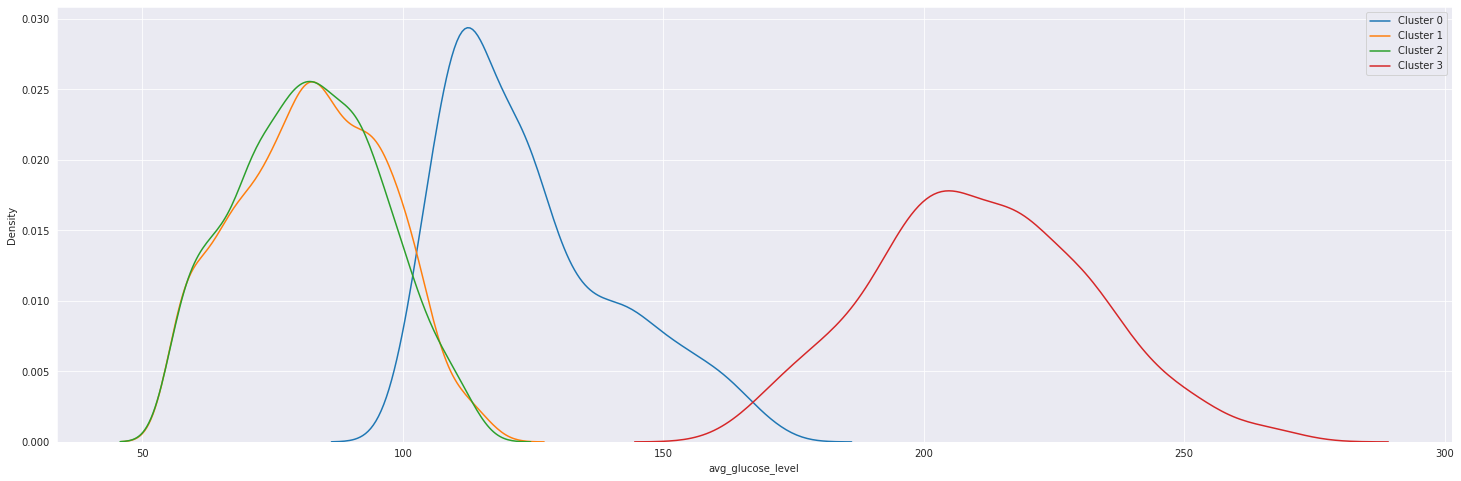

In [25]:
plt.figure(figsize = (25,8))
sb.kdeplot(df_0['avg_glucose_level'],label = 'Cluster 0')
sb.kdeplot(df_1['avg_glucose_level'],label = 'Cluster 1')
sb.kdeplot(df_2['avg_glucose_level'],label = 'Cluster 2')
sb.kdeplot(df_3['avg_glucose_level'],label = 'Cluster 3')
plt.legend();

* Average Glucose Level for cluster 0 is 124.505
* Average Glucose Level for cluster 1 is 82.705
* Average Glucose Level for cluster 2 is 82.095
* Average Glucose Level for cluster 3 is 211.075


<h3> BMI Distribution

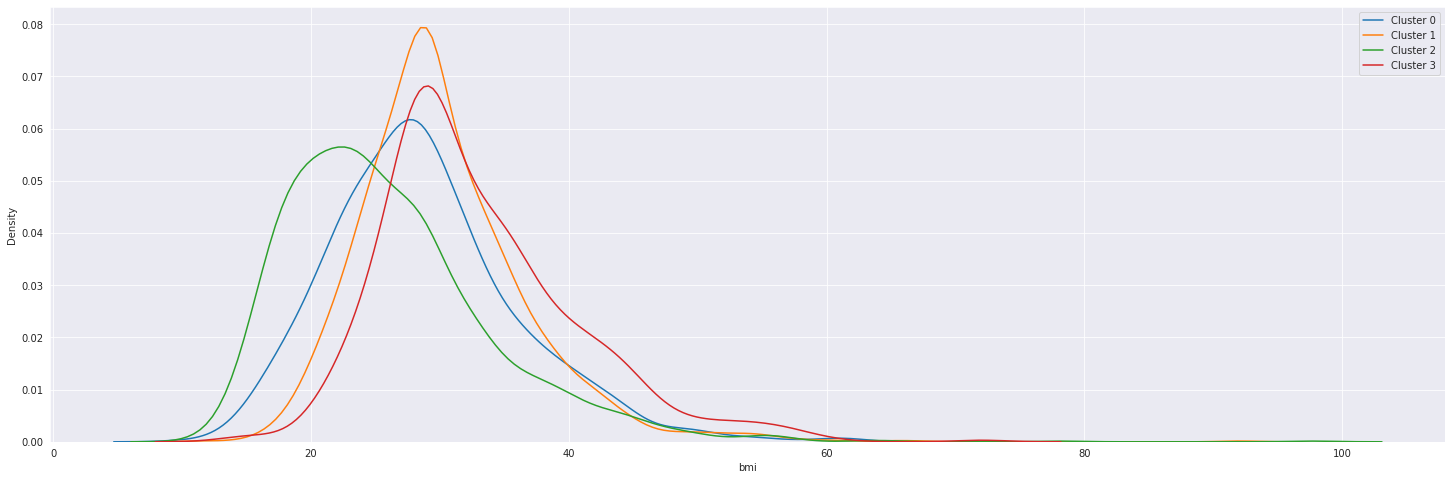

In [26]:
plt.figure(figsize = (25,8))
sb.kdeplot(df_0['bmi'],label = 'Cluster 0')
sb.kdeplot(df_1['bmi'],label = 'Cluster 1')
sb.kdeplot(df_2['bmi'],label = 'Cluster 2')
sb.kdeplot(df_3['bmi'],label = 'Cluster 3')
plt.legend();

* Average BMI for cluster 0 is 28.756
* Average BMI for cluster 1 is 30.21
* Average BMI for cluster 2 is 25.90
* Average BMI for cluster 3 is 32.95

# Preprocessing

In [27]:
data.skew()

gender              -0.345664
age                 -0.137059
hypertension         2.715392
heart_disease        3.947244
ever_married         0.657745
work_type            0.972287
Residence_type       0.032107
avg_glucose_level    1.572284
bmi                  1.076716
smoking_status       0.077863
stroke               4.193284
Cluster              0.108257
dtype: float64

In [28]:
data['age'] = data['age']/data['age'].max()
data['avg_glucose_level'] = data['avg_glucose_level']/data['avg_glucose_level'].max()
data['bmi'] = data['bmi']/data['bmi'].max()

In [29]:
data

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,Cluster
0,0,0.817073,0,1,0,0,0,0.841577,0.375000,0,1,3
1,1,0.743902,0,0,0,1,1,0.744130,0.296037,1,1,3
2,0,0.975610,0,1,0,0,1,0.389784,0.332992,1,1,1
3,1,0.597561,0,0,0,0,0,0.630124,0.352459,2,1,3
4,1,0.963415,1,0,0,1,1,0.640760,0.245902,1,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,1,0.975610,1,0,0,0,0,0.308199,0.296037,1,0,1
5106,1,0.987805,0,0,0,1,0,0.460735,0.409836,1,0,0
5107,1,0.426829,0,0,0,1,1,0.305402,0.313525,1,0,2
5108,0,0.621951,0,0,0,0,1,0.611945,0.262295,0,0,0


<h1> Creating Machine Learning Models without including Clustering

In [30]:
X = data.iloc[:,:10]
y = data['stroke']

In [31]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size = 0.25,random_state=1)

<h2> Creating a function to evaluate model performance </h2>

In [32]:
def model_performance(model,x_train = x_train,x_test = x_test,y_train = y_train,y_test = y_test):
    print(f"{model} Performance:\n")
    y_train_pred = cross_val_predict(model,x_train,y_train,cv=4)
    plt.figure(figsize = (10,10))
    sb.heatmap(confusion_matrix(y_train,y_train_pred),annot = True)
    plt.title('Confusion Matrix')
    plt.show()
    precision_score_ = precision_score(y_train,y_train_pred)
    recall_score_ = recall_score(y_train,y_train_pred)
    accuracy_score_ = accuracy_score(y_train,y_train_pred)
    cross_val_score_insample = cross_val_score(model,x_train,y_train,cv=4,scoring='accuracy').mean()
    cross_val_score_outsample = cross_val_score(model,x_test,y_test,cv=4,scoring='accuracy').mean()
    print('Precision Score:',precision_score_)
    print("Recall Score:",recall_score_)
    print("Accuracy Score:",accuracy_score_)
    print("Cross Val Score Insample",cross_val_score_insample)
    print("Cross Val Score Outsample",cross_val_score_outsample)
    
    return model,precision_score_,recall_score_,accuracy_score_,cross_val_score_insample,cross_val_score_outsample

<h2> Logistic Regression

In [33]:
clf1 = LogisticRegression()
clf1.fit(x_train,y_train)

LogisticRegression()

LogisticRegression() Performance:



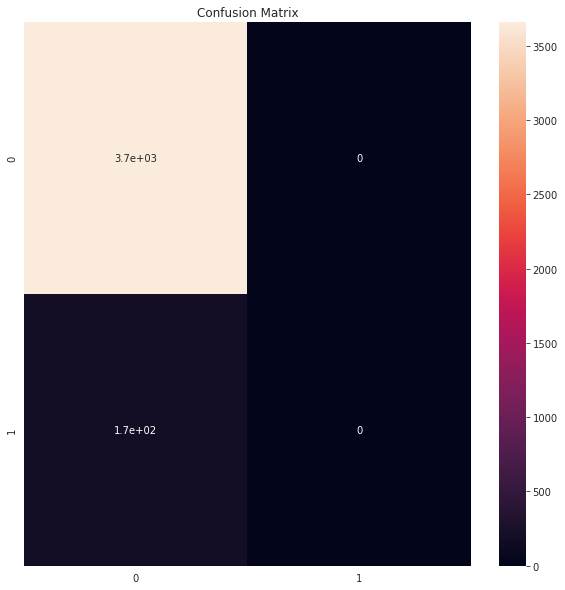

Precision Score: 0.0
Recall Score: 0.0
Accuracy Score: 0.9545929018789144
Cross Val Score Insample 0.9545929018789144
Cross Val Score Outsample 0.939748236677116


In [34]:
lr_performance_1 = model_performance(clf1)

<h2>KNN

In [35]:
clf2 = KNeighborsClassifier()
clf2.fit(x_train,y_train)

KNeighborsClassifier()

KNeighborsClassifier() Performance:



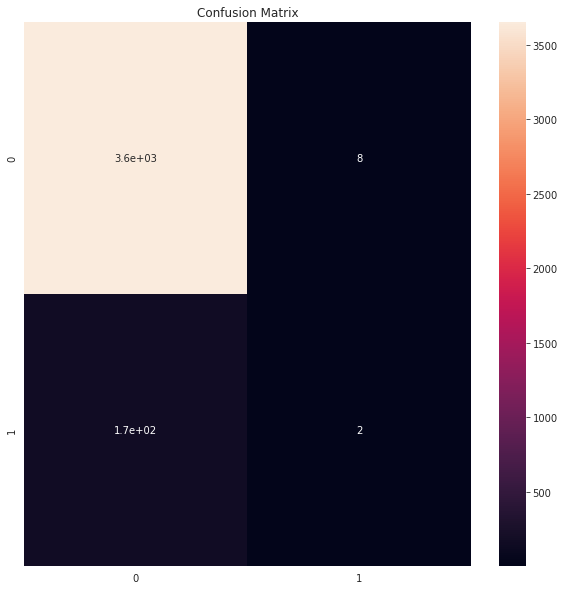

Precision Score: 0.2
Recall Score: 0.011494252873563218
Accuracy Score: 0.9530271398747391
Cross Val Score Insample 0.9530271398747391
Cross Val Score Outsample 0.9358395376175549


In [36]:
knn_performance_1 = model_performance(clf2)

<h2> DecisionTreeClassifier </h2>

In [37]:
clf3 = DecisionTreeClassifier()
clf3.fit(x_train,y_train)

DecisionTreeClassifier()

DecisionTreeClassifier() Performance:



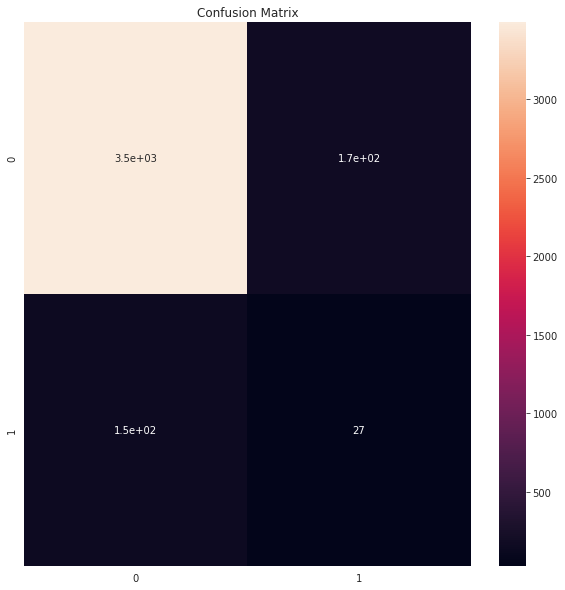

Precision Score: 0.13846153846153847
Recall Score: 0.15517241379310345
Accuracy Score: 0.9177974947807933
Cross Val Score Insample 0.9170146137787056
Cross Val Score Outsample 0.902211500783699


In [38]:
dtc_performance_1 = model_performance(clf3)

<h2> Random Forest Classifier

In [39]:
clf4 = RandomForestClassifier()
clf4.fit(x_train,y_train)

RandomForestClassifier()

RandomForestClassifier() Performance:



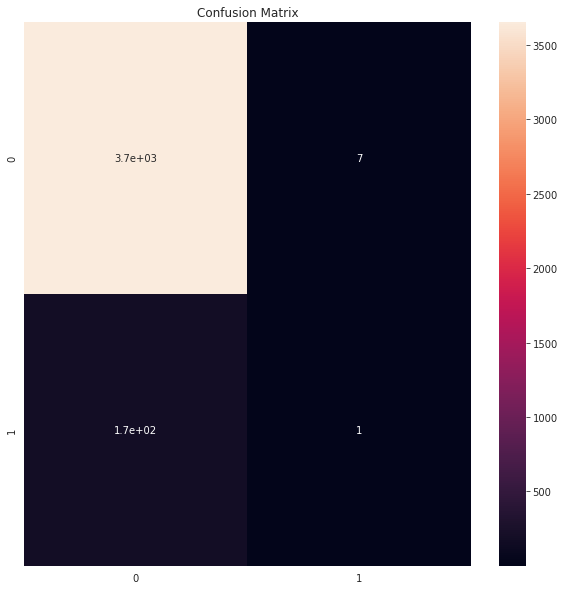

Precision Score: 0.125
Recall Score: 0.005747126436781609
Accuracy Score: 0.9530271398747391
Cross Val Score Insample 0.9532881002087682
Cross Val Score Outsample 0.9397506857366771


In [40]:
rd_performance_1 = model_performance(clf4)

<h1>Creating Machine Learning Classification models with Clustering

In [41]:
X = data[['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status','Cluster']]
y = data['stroke']

In [42]:
X

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,Cluster
0,0,0.817073,0,1,0,0,0,0.841577,0.375000,0,3
1,1,0.743902,0,0,0,1,1,0.744130,0.296037,1,3
2,0,0.975610,0,1,0,0,1,0.389784,0.332992,1,1
3,1,0.597561,0,0,0,0,0,0.630124,0.352459,2,3
4,1,0.963415,1,0,0,1,1,0.640760,0.245902,1,3
...,...,...,...,...,...,...,...,...,...,...,...
5105,1,0.975610,1,0,0,0,0,0.308199,0.296037,1,1
5106,1,0.987805,0,0,0,1,0,0.460735,0.409836,1,0
5107,1,0.426829,0,0,0,1,1,0.305402,0.313525,1,2
5108,0,0.621951,0,0,0,0,1,0.611945,0.262295,0,0


In [43]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size = 0.25,random_state = 1)

<h2>Logistic Regression

In [44]:
model1 = LogisticRegression()
model1.fit(x_train,y_train)

LogisticRegression()

LogisticRegression() Performance:



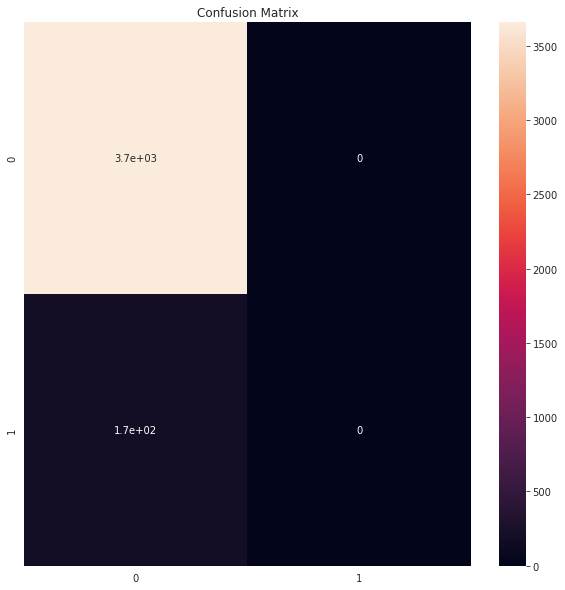

Precision Score: 0.0
Recall Score: 0.0
Accuracy Score: 0.9545929018789144
Cross Val Score Insample 0.9545929018789144
Cross Val Score Outsample 0.939748236677116


In [45]:
lr_performance_2 = model_performance(model1)

<h2> KNN

In [46]:
model2 = KNeighborsClassifier()
model2.fit(x_train,y_train)

KNeighborsClassifier()

KNeighborsClassifier() Performance:



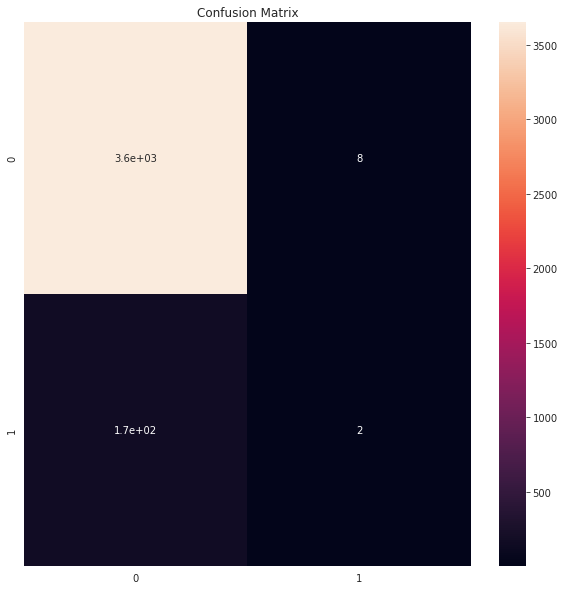

Precision Score: 0.2
Recall Score: 0.011494252873563218
Accuracy Score: 0.9530271398747391
Cross Val Score Insample 0.9530271398747391
Cross Val Score Outsample 0.9358395376175549


In [47]:
knn_performance_2 = model_performance(model2)

<h2> Decision Tree Classifier

In [48]:
model3 = DecisionTreeClassifier()
model3.fit(x_train,y_train)

DecisionTreeClassifier()

DecisionTreeClassifier() Performance:



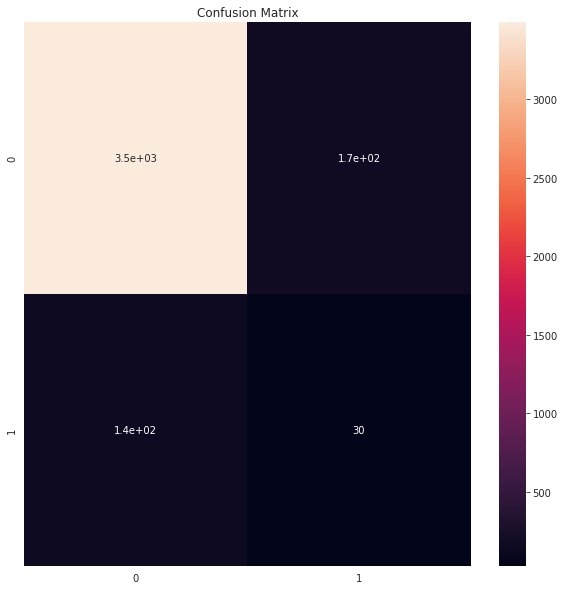

Precision Score: 0.15
Recall Score: 0.1724137931034483
Accuracy Score: 0.9180584551148225
Cross Val Score Insample 0.9175365344467641
Cross Val Score Outsample 0.893595709247649


In [49]:
dtc_performance_2 = model_performance(model3)

<h2> Random Forest Classifier </h1>

In [50]:
model4 = RandomForestClassifier()
model4.fit(x_train,y_train)

RandomForestClassifier()

RandomForestClassifier() Performance:



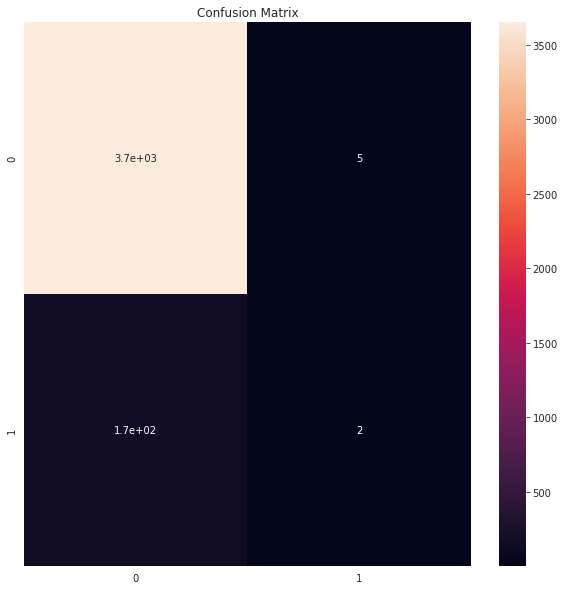

Precision Score: 0.2857142857142857
Recall Score: 0.011494252873563218
Accuracy Score: 0.9538100208768268
Cross Val Score Insample 0.9535490605427975
Cross Val Score Outsample 0.9413156347962383


In [51]:
rd_performance_2 = model_performance(model4)

# Comparing Results

In [52]:
results_without_clustering = pd.DataFrame([lr_performance_1,knn_performance_1,dtc_performance_1,rd_performance_1],columns = ['model','precision_score','recall_score','accuracy_score','cross_val_score_insample','cross_val_score_outsample'])
results_without_clustering

,model,precision_score,recall_score,accuracy_score,cross_val_score_insample,cross_val_score_outsample
0,LogisticRegression(),0.000000,0.000000,0.954593,0.954593,0.939748
1,KNeighborsClassifier(),0.200000,0.011494,0.953027,0.953027,0.935840
2,DecisionTreeClassifier(),0.138462,0.155172,0.917797,0.917015,0.902212
3,"(DecisionTreeClassifier(max_features='auto', r...",0.125000,0.005747,0.953027,0.953288,0.939751


In [53]:
results_with_clustering = pd.DataFrame([lr_performance_2,knn_performance_2,dtc_performance_2,rd_performance_2],columns = ['model','precision_score','recall_score','accuracy_score','cross_val_score_insample','cross_val_score_outsample'])
results_with_clustering

,model,precision_score,recall_score,accuracy_score,cross_val_score_insample,cross_val_score_outsample
0,LogisticRegression(),0.000000,0.000000,0.954593,0.954593,0.939748
1,KNeighborsClassifier(),0.200000,0.011494,0.953027,0.953027,0.935840
2,DecisionTreeClassifier(),0.150000,0.172414,0.918058,0.917537,0.893596
3,"(DecisionTreeClassifier(max_features='auto', r...",0.285714,0.011494,0.953810,0.953549,0.941316
